In [1]:
import torch
import torchcde
import pandas as pd
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Subset, Dataset,random_split
from torchvision.datasets import DatasetFolder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import random
from tqdm import tqdm
import matplotlib.pyplot as plt

n_sensors=13
decimals=1
epochs=20
batch_size=1
lr=1e-2
spf = 0.1  # reciprocal of frames per second
fc_hidden=128
accumulation_steps = 8
eps = 1e-6

# set threshold for minimum observations per sensor (change as needed)
min_obs = 10

In [2]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(42)

In [4]:
raw_df = pd.read_csv("E:/CoDaS Project/Radar/C3/radar_merged_data.csv")
raw_df['timestamp'] = raw_df['timestamp'].round(decimals)  # Round timestamps to the specified number of decimal places for consistency

In [5]:
# Set sensor columns to NaN if they have insufficient observations for each user and emotion
for (u, e), idx in raw_df.groupby(['user_id', 'emotion']).groups.items():
    for s in range(n_sensors):
        observed = raw_df.loc[idx, f'x_{s}'].count()
        if observed < min_obs and observed > 0:  # if there are some observations but not enough
            #print(f"User {u}, Emotion {e}, Sensor {s} has insufficient data, only {observed} observations. Setting to NaN.")
            raw_df.loc[idx,[f'x_{s}', f'y_{s}', f'z_{s}']] = np.nan

# Drop empty rows after setting insufficient sensor data to NaN
raw_df = raw_df.set_index(['user_id', 'emotion', 'timestamp']).dropna(how='all').reset_index()

In [6]:
le = LabelEncoder()
le.fit(raw_df['emotion'].unique())
n_classes = len(le.classes_)

In [51]:
unique_users = raw_df['user_id'].unique()
train_users, test_users = train_test_split(unique_users, test_size=int(0.2*(len(unique_users))), random_state=42)
train_users, valid_users = train_test_split(train_users, test_size=int(0.2*(len(unique_users))), random_state=42)
train_df, test_df = raw_df[raw_df['user_id'].isin(train_users)], raw_df[raw_df['user_id'].isin(test_users)]
valid_df = raw_df[raw_df['user_id'].isin(valid_users)]

train_df.set_index(['user_id','emotion'], inplace=True)
valid_df = test_df.set_index(['user_id','emotion'])
test_df.set_index(['user_id','emotion'], inplace=True)

In [8]:
def compute_delta_t(times, mask):
    T, S = mask.shape
    delta_t = np.full((T, S), np.nan, dtype=float)

    last_obs_time = np.full(S, np.nan)

    for t in range(T):
        observed = mask[t].astype(bool)

        # Reset timer for observed sensors
        delta_t[t, observed] = 0.0
        last_obs_time[observed] = times[t]

        # Compute elapsed time for missing sensors that have been seen before
        missing = ~observed
        has_previous = ~np.isnan(last_obs_time)

        valid = missing & has_previous
        delta_t[t, valid] = times[t] - last_obs_time[valid]

    return delta_t

In [9]:
def process_input_sequence(raw_sequence):
    raw_sequence = raw_sequence.sort_values("timestamp")
    # mask for each sensor: True if observed else false
    sensor_mask = raw_sequence.drop(columns=['timestamp']).notna().to_numpy()[:,::3]

    timestamps = raw_sequence["timestamp"].to_numpy()

    sensor_cols = raw_sequence.columns.drop("timestamp")
    mean_values = raw_sequence[sensor_cols].mean()
    std_values = raw_sequence[sensor_cols].std()

    # Center the sensor values by subtracting the mean and scaling by the standard deviation
    raw_sequence[sensor_cols]-= mean_values
    #raw_sequence[sensor_cols]/= (std_values + eps)

    filled_sequence = raw_sequence.ffill()

    #time_since_last_obs = compute_delta_t(timestamps, sensor_mask)

    #filled_sequence = np.concatenate([filled_sequence, sensor_mask, time_since_last_obs],axis=-1)
    filled_sequence = np.concatenate([filled_sequence, sensor_mask],axis=-1)
    filled_sequence = torch.tensor(filled_sequence, dtype=torch.float32)

    timestamps = torch.tensor(timestamps, dtype=torch.float32)

    #mean_values = torch.tensor(mean_values.values, dtype=torch.float32)
    #std_values = torch.tensor(std_values.values, dtype=torch.float32)

    return filled_sequence, timestamps, mean_values, std_values

def process_target_sequence(target_values, input_mean, input_std):
    target_values = target_values.sort_values("timestamp")
    target_timestamps = target_values['timestamp'].values

    target_values = target_values.drop(columns=['timestamp'])
    target_values = (target_values - input_mean)# / (input_std + eps)

    target_mask = target_values.notna().values

    target_values = target_values.fillna(0).values  # Fill NaN values with 0 for processing
    
    # Convert to torch tensor
    target_values = torch.tensor(target_values, dtype=torch.float32)
    target_mask = torch.tensor(target_mask, dtype=torch.bool)
    target_timestamps = torch.tensor(target_timestamps, dtype=torch.float32)
    
    return target_timestamps, target_values, target_mask

In [10]:
class RadarSequenceDataset(Dataset):
    def __init__(self, df,test=False):
        """
        Args:
            df: DataFrame with radar data
            test: Boolean indicating if the dataset is for testing
        """
        # Split data
        self.df = df
        self.experiments = df.index.unique()
        self.test = test
    
    def __len__(self):
        return len(self.experiments)
    
    def __getitem__(self, idx):
        experiment = self.experiments[idx]
        user_id, emotion = experiment
        experiment_data = self.df.loc[experiment].groupby("timestamp", as_index=False).mean()

        t_max = experiment_data["timestamp"].max()
        t_min = experiment_data["timestamp"].min()
        experiment_data["timestamp"] = (experiment_data["timestamp"] - t_min) / (t_max - t_min)  # Normalize timestamps to [0, 1]
        p = random.uniform(0.1, 0.3)
        # Split into input and target sequences
        if not self.test:
            input_sequence, target_sequence = train_test_split(experiment_data, test_size=p)
        else:
            input_sequence, target_sequence = train_test_split(experiment_data, test_size=0.2, random_state=42)

        # Process using existing function
        input_sequence, input_timestamps, input_mean, input_std = process_input_sequence(input_sequence)
        target_timestamp, target_sequence, target_mask = process_target_sequence(target_sequence, input_mean, input_std)
        
        return (input_sequence, input_timestamps), (target_timestamp, target_sequence, target_mask), emotion


# Create train and test datasets
train_dataset = RadarSequenceDataset(train_df)
valid_dataset = RadarSequenceDataset(valid_df, test=True)

test_dataset = RadarSequenceDataset(test_df, test=True)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=1, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [11]:
# Create model
input_channels = n_sensors*4 + 1
hidden_channels = 128  # hyperparameter, we can pick whatever we want for this
output_channels = n_sensors*3  # e.g. to perform 10-way multiclass classification
    
class CDEFunc(nn.Module):
    def __init__(self):
        super(CDEFunc, self).__init__()

        self.hidden_channels = hidden_channels
        self.input_channels = input_channels

        self.net = nn.Sequential(
            nn.Linear(hidden_channels+1, 128),
            nn.ReLU(),
            nn.Linear(128, hidden_channels * input_channels),
            nn.Tanh()
        )

    def forward(self, t, z):        
        inp = torch.cat([z, t.reshape(1, 1)], dim=-1)
        out = self.net(inp)
        out = 1e-3 * out.view(
            z.size(0),
            self.hidden_channels,
            self.input_channels
        )

        return out

class Model(torch.nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.hidden_channels = hidden_channels
        self.input_channels = input_channels
        
        self.initial = nn.Sequential(
            nn.Linear(input_channels, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, hidden_channels)
        )
        self.func = CDEFunc()
        self.readout = nn.Sequential(
            nn.Linear(hidden_channels, 128),
            nn.ReLU(),

            #nn.Linear(256, 128),
            #nn.ReLU(),

            nn.Linear(128, output_channels)
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_channels, 128),
            nn.ReLU(),

            #nn.Linear(256, 128),
            #nn.ReLU(),

            nn.Linear(128, n_classes),
        )

    def forward(self, coeffs,timestamps,target_timestamps):
        X = torchcde.CubicSpline(coeffs,t=timestamps)
        X0 = X.evaluate(X.interval[0])
        z0 = self.initial(X0)
        zt = torchcde.cdeint(X=X, func=self.func, z0=z0, t=target_timestamps,method="rk4")

        classifier_input = torchcde.cdeint(X=X, func=self.func, z0=z0, t=X.interval,method="rk4")
        
        return self.readout(zt), self.classifier(classifier_input[:,-1,:])

model = Model().to(device)
model_name = "ncde"

In [12]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=lr
)

criterion = nn.MSELoss()
criterion2 = nn.CrossEntropyLoss()

In [13]:
train_loss_history = []
valid_loss_history = []

best_interp_loss = np.inf
best_classify_loss = np.inf

print("\n=== TRAINING START ===")
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    epoch_classify_loss=0
    
    optimizer.zero_grad()

    pbar = tqdm(train_loader, desc=f"epoch {epoch+1}/{epochs}", leave=False)
    for i, ((input_seq, ts), (target_ts, target_seq, target_mask), emotion) in enumerate(pbar):
        # Move inputs to selected device
        input_seq = input_seq.to(device)
        ts = ts.squeeze(0).to(device)
        emotion = torch.tensor(le.transform(emotion), dtype=torch.long,device=device)

        target_seq, target_mask = target_seq.to(device), target_mask.to(device)
        target_ts = target_ts.squeeze(0).to(device)

        coeffs = torchcde.hermite_cubic_coefficients_with_backward_differences(input_seq,t=ts)

        #optimizer.zero_grad()
        output,emotion_prob = model(coeffs,ts, target_ts)
        #output = model(coeffs,ts, target_ts)
        loss = criterion(output[target_mask], target_seq[target_mask]) / accumulation_steps
        classification_loss=criterion2(emotion_prob,emotion) / accumulation_steps
        loss+=classification_loss
        loss.backward()

        if (i + 1) % accumulation_steps == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            optimizer.zero_grad()

        epoch_loss += loss.item()
        epoch_classify_loss+=classification_loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}",classify_loss=f"{classification_loss.item():.4f}")
        
    if len(train_loader) % accumulation_steps != 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        optimizer.zero_grad()
    
    train_loss_history.append(epoch_loss / len(train_loader))
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader)}, Classify Loss: {epoch_classify_loss/len(train_loader)}")

    valid_loss = 0
    valid_classify_loss=0
    for (input_seq, ts), (target_ts, target_seq, target_mask), emotion in valid_loader:
        # Move inputs to selected device
        input_seq = input_seq.to(device)
        ts = ts.squeeze(0).to(device)

        target_seq, target_mask = target_seq.to(device), target_mask.to(device)
        target_ts = target_ts.squeeze(0).to(device)
        emotion = torch.tensor(le.transform(emotion), dtype=torch.long,device=device)

        coeffs = torchcde.hermite_cubic_coefficients_with_backward_differences(input_seq,t=ts)

        model.eval()
        with torch.no_grad():
            output,emotion_prob = model(coeffs,ts, target_ts)
            #output = model(coeffs,ts, target_ts)
            loss = criterion(output[target_mask], target_seq[target_mask])
            valid_loss += loss.item()
            valid_classify_loss += criterion2(emotion_prob,emotion).item()
    valid_loss /= len(valid_loader)
    valid_classify_loss /= len(valid_loader)
    valid_loss_history.append(valid_loss+valid_classify_loss)

    if valid_loss < best_interp_loss:
        best_interp_loss = valid_loss
        torch.save(model.state_dict(), f"{model_name}_best_model_interp.pth")
        print(f"New best interpolation loss: {best_interp_loss}. Model saved as {model_name}_best_model_interp.pth")
    if valid_classify_loss < best_classify_loss:
        best_classify_loss = valid_classify_loss
        torch.save(model.state_dict(), f"{model_name}_best_model_classify.pth")
        print(f"New best classification loss: {best_classify_loss}. Model saved as {model_name}_best_model_classify.pth")
    print(f"Valid Loss: {valid_loss}, Valid Classify Loss: {valid_classify_loss}")


=== TRAINING START ===


Epoch 1/20, Loss: 0.25970718637108803, Classify Loss: 0.24787132180543667
New best interpolation loss: 0.08333644022544225. Model saved as best_model_interp.pth
New best classification loss: 2.6193915711094937. Model saved as best_model_classify.pth
Valid Loss: 0.08333644022544225, Valid Classify Loss: 2.6193915711094937


Epoch 2/20, Loss: 0.2588043745367899, Classify Loss: 0.24718066854637388
New best interpolation loss: 0.07881649299007323. Model saved as best_model_interp.pth
New best classification loss: 2.4950458572970495. Model saved as best_model_classify.pth
Valid Loss: 0.07881649299007323, Valid Classify Loss: 2.4950458572970495


Epoch 3/20, Loss: 0.291657606592624, Classify Loss: 0.280337691417609
New best interpolation loss: 0.07850793743919995. Model saved as best_model_interp.pth
Valid Loss: 0.07850793743919995, Valid Classify Loss: 2.8274914565392666


Epoch 4/20, Loss: 0.25060654967305585, Classify Loss: 0.23910839130264627
New best interpolation loss: 0.07842433504346344. Model saved as best_model_interp.pth
New best classification loss: 1.8393872494084968. Model saved as best_model_classify.pth
Valid Loss: 0.07842433504346344, Valid Classify Loss: 1.8393872494084968


...

Epoch 16/20, Loss: 0.39774413881908866, Classify Loss: 0.20220023887167252
Valid Loss: 0.08009526568154494, Valid Classify Loss: 5.537373392719827


Epoch 17/20, Loss: 0.1585101834711952, Classify Loss: 0.1468273448873959
Valid Loss: 0.07864363450143072, Valid Classify Loss: 4.35957656373244


Epoch 18/20, Loss: 0.17114305464174906, Classify Loss: 0.15916120415632798
Valid Loss: 0.07851909416624242, Valid Classify Loss: 4.558678147460644


Epoch 19/20, Loss: 0.1185873255876978, Classify Loss: 0.06443651156849109
Valid Loss: 0.07866114274495178, Valid Classify Loss: 5.867627372547052


Epoch 20/20, Loss: 0.11203999465775735, Classify Loss: 0.09932758762484999
Valid Loss: 0.07903985084137982, Valid Classify Loss: 5.333506345793669


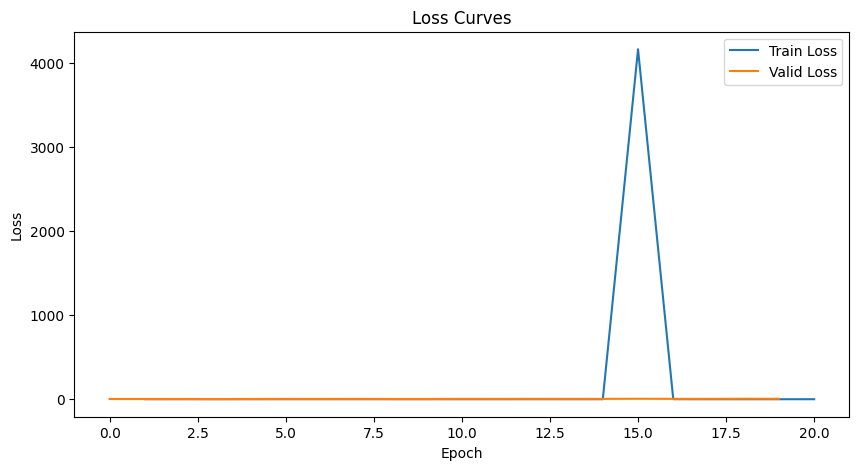

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_loss_history, label="Train Loss")
plt.plot(valid_loss_history, label="Valid Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()

In [15]:
torch.save(model.state_dict(), f"{model_name}_model.pth")

In [20]:
model.load_state_dict(torch.load(f"{model_name}_best_model_classify.pth",map_location=device))

<All keys matched successfully>

In [21]:
test_loss = 0
test_classify_loss=0
labels=[]
preds=[]
for (input_seq, ts), (target_ts, target_seq, target_mask), emotion in test_loader:
    # Move inputs to selected device
    input_seq = input_seq.to(device)
    ts = ts.squeeze(0).to(device)

    target_seq, target_mask = target_seq.to(device), target_mask.to(device)
    target_ts = target_ts.squeeze(0).to(device)
    emotion = le.transform(emotion)
    labels.append(emotion)

    emotion = torch.tensor(emotion, dtype=torch.long,device=device)

    coeffs = torchcde.hermite_cubic_coefficients_with_backward_differences(input_seq,t=ts)

    model.eval()
    with torch.no_grad():
        output,emotion_prob = model(coeffs,ts, target_ts)
        #output = model(coeffs,ts, target_ts)
        loss = criterion(output[target_mask], target_seq[target_mask])
        test_loss += loss.item()
        test_classify_loss += criterion2(emotion_prob,emotion).item()
        preds.append(emotion_prob.argmax(-1).item())
test_loss /= len(test_loader)
test_classify_loss /= len(test_loader)

print(f"Test Loss: {test_loss}, Test Classify Loss: {test_classify_loss}")
print(f"Accuracy:{accuracy_score(labels,preds)}")

Test Loss: 0.09961434008760585, Test Classify Loss: 1.7683456430418625
Accuracy:0.2222222222222222


Text(0.5, 1.0, 'Confusion Matrix for XGBoost Classifier')

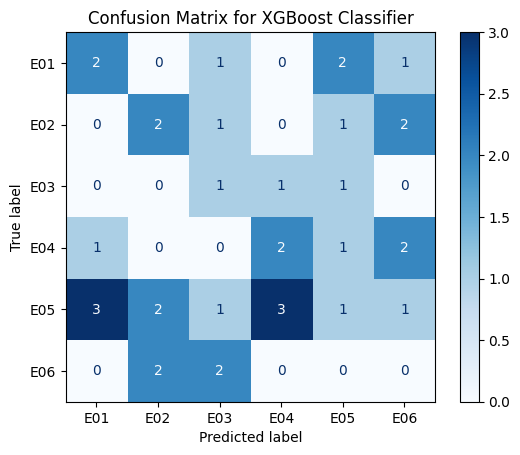

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(preds, labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for XGBoost Classifier")

In [13]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import SplineTransformer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

def fit_predict_spline_ridge(input_ts,input_values, target_ts):

    X_train = np.asarray(input_ts).reshape(-1, 1)
    y_train = np.asarray(input_values)
    X_test = np.asarray(target_ts).reshape(-1, 1)

    model = make_pipeline(
        SplineTransformer(n_knots=4, degree=3),
        Ridge(alpha=1e-3)
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return y_pred

In [14]:
#Currently, if only one sensor has no observations, entire sequence is discarded.

In [15]:
def separate_sensor_data_and_predict(input_seq, target_ts, target_seq, target_mask):
    timestamps = input_seq[:, 0]
    sensor_values = input_seq[:, 1:1 + n_sensors * 3].reshape(len(timestamps), n_sensors, 3)
    sensor_mask = input_seq[:, 1 + n_sensors * 3:].astype(bool)

    sensor_predictions = np.zeros_like(target_seq)

    mse_loss = 0
    for sensor_idx in range(n_sensors):
        observed_idx = sensor_mask[:, sensor_idx]
        sensor_idx_ts = timestamps[observed_idx]
        sensor_idx_values = sensor_values[observed_idx, sensor_idx, :]

        if sensor_idx_values.shape[0] < min_obs:
            continue

        y_pred = fit_predict_spline_ridge(sensor_idx_ts, sensor_idx_values, target_ts)
        sensor_predictions[:, sensor_idx] = y_pred

    mse_loss = mean_squared_error(target_seq[target_mask], sensor_predictions[target_mask])
    return sensor_predictions, mse_loss


In [34]:
test_loss = 0
for (input_seq, ts), (target_ts, target_seq, target_mask), emotion in test_loader:
    input_seq = input_seq.squeeze(0).cpu().numpy()
    ts = ts.squeeze(0).cpu().numpy()
    target_seq = target_seq.squeeze(0).cpu().numpy().reshape(-1, n_sensors, 3)
    target_mask = target_mask.squeeze(0).cpu().numpy().reshape(-1, n_sensors, 3)
    target_ts = target_ts.squeeze(0).cpu().numpy()

    sensor_predictions, mse_loss = separate_sensor_data_and_predict(input_seq, target_ts, target_seq, target_mask)
    test_loss += mse_loss
    
print(f"Test Loss (Spline + Ridge): {test_loss / len(test_loader)}")

Test Loss (Spline + Ridge): 0.09627970721986559


In [37]:
sensor_predictions[:,sensor_id,axis_idx]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0.], dtype=float32)

In [41]:
target_mask.sum()

210

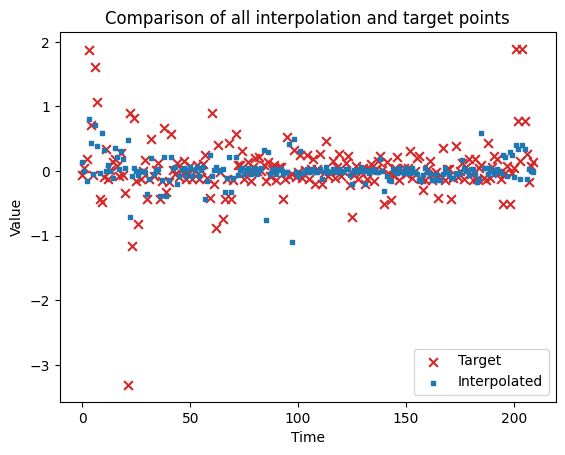

In [47]:
axis_names = ['x', 'y', 'z']

plt.scatter(range(target_mask.sum()), target_seq[target_mask], label="Target", color="tab:red", marker="x", s=40)
plt.scatter(range(target_mask.sum()), sensor_predictions[target_mask], label="Interpolated", color="tab:blue", marker="s", s=10)
plt.title(f"Comparison of all interpolation and target points")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()


In [27]:
sensor_predictions.shape

(55, 13, 3)

In [32]:
target_mask[:,sensor_id,axis_idx].shape

(55,)

In [33]:
target_seq[target_mask[:,sensor_id,axis_idx]].shape

(0, 13, 3)

In [17]:
spline_interp = pd.read_csv("E:/CoDaS Project/Radar/C3/radar_interpolated_merged_data.csv", 
                            usecols=['timestamp', 'user_id', 'emotion'])
end_time = spline_interp.groupby(['user_id', 'emotion']).max()

nn_interpolated_data = []
emotion_labels = []
emotion_predictions = []
# Interpolate for each experiment in the test dataset using entire sequence

model.eval()
for experiment in test_dataset.experiments:
    user_id, class_key = experiment
    sync_end = end_time.loc[experiment]['timestamp']
    interp_timestamps = np.arange(0, sync_end, step=spf)
    interp_timestamps = torch.tensor(interp_timestamps, dtype=torch.float32)


    input_sequence = test_df.loc[experiment].groupby("timestamp", as_index=False).mean()

    input_sequence, input_timestamps, mean, std = process_input_sequence(input_sequence)


    input_sequence = input_sequence.unsqueeze(0).to(device)  # Add batch dimension
    input_timestamps = input_timestamps.to(device)  # Input timestamps doesn't need batch dimension
    interp_timestamps = interp_timestamps.to(device)  # Add batch dimension

    coeffs = torchcde.hermite_cubic_coefficients_with_backward_differences(input_sequence,t=input_timestamps)
    
    with torch.no_grad():
        pred, emotion_prob = model(coeffs, input_timestamps, interp_timestamps)  # Remove batch dimension
        pred = pred.squeeze(0)  # Remove batch dimension
        emotion_prob = emotion_prob.squeeze(0)  # Remove batch dimension

    pred = pred.cpu().numpy() * (std.values + eps) + mean.values  # Denormalize the predictions
    #pred = pred.cpu().numpy() + mean.values  # Denormalize the predictions

    emotion_prob = torch.argmax(emotion_prob, dim=-1).item()
    pred_emotion = le.inverse_transform([emotion_prob])[0]

    pred = np.concatenate([interp_timestamps.unsqueeze(-1).cpu().numpy(), pred], axis=-1)
    interp_df = pd.DataFrame(pred, columns=test_df.columns)
    
    interp_df.insert(0, 'user_id', user_id)
    interp_df.insert(1, 'emotion', class_key)

    nn_interpolated_data.append(interp_df)

    emotion_labels.append(class_key)
    emotion_predictions.append(pred_emotion)
    
radar_interp_df = pd.concat(nn_interpolated_data, ignore_index=False)
radar_interp_df.to_csv("E:/CoDaS Project/Radar/C3/radar_nn_test_interpolated_data.csv", index=False)

KeyError: 'E01'

In [ ]:
print("accuracy:", np.mean(np.array(emotion_labels) == np.array(emotion_predictions)))

accuracy: 0.16666666666666666


Text(0.5, 1.0, 'Confusion Matrix for XGBoost Classifier')

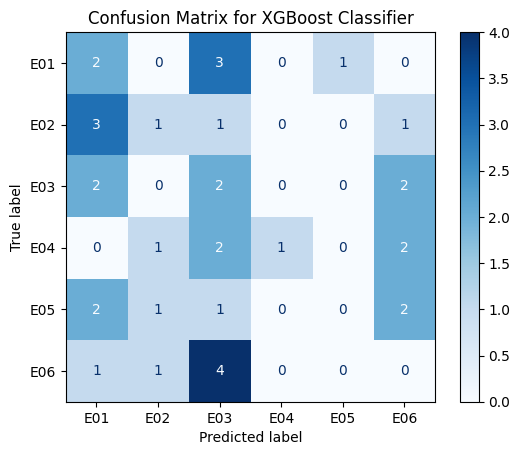

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(emotion_labels, emotion_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for XGBoost Classifier")